In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<Axes: xlabel='Time [YYYY-MM-DD HH:MM:SS UTC]'>

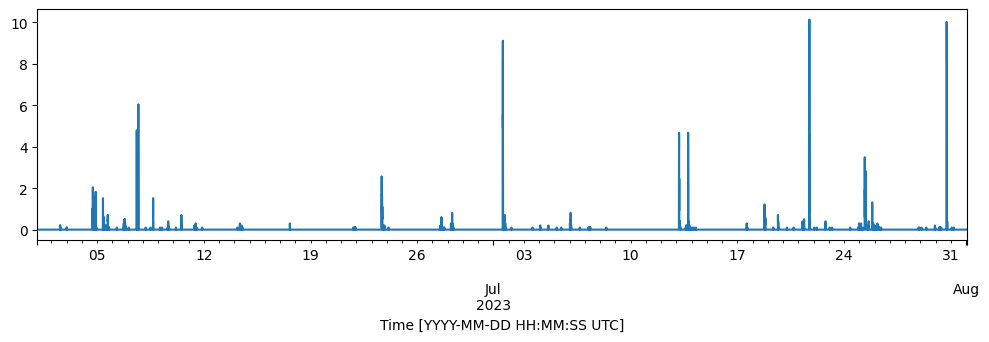

In [138]:
df_p = pd.read_csv("p_2023-06-01-2023-07-31.csv")
df_p["Time [YYYY-MM-DD HH:MM:SS UTC]"] = pd.to_datetime(df_p["Time [YYYY-MM-DD HH:MM:SS UTC]"])
s_p = df_p.set_index("Time [YYYY-MM-DD HH:MM:SS UTC]")["Precipitation [mm]"].shift(freq="2h")
s_p.plot(drawstyle="steps-pre", figsize=(12, 3))

# Get Baseflow

<Axes: xlabel='Time'>

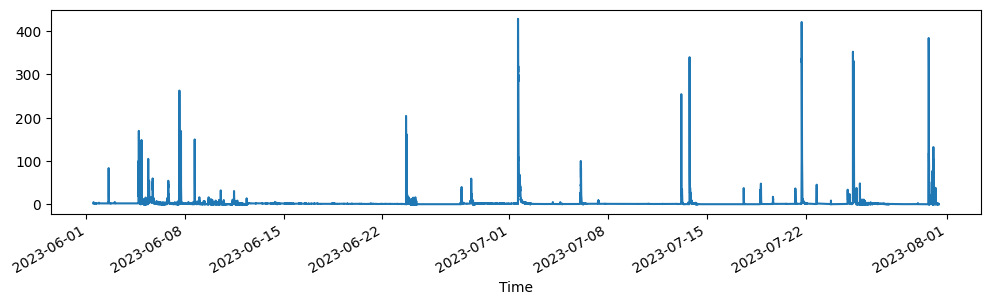

In [139]:
df_q = pd.read_csv("q_2023-06-01-2023-07-31.csv")
df_q["Time"] = pd.to_datetime(df_q["Time"])
s_q = df_q.set_index("Time")["Q-Daten_Oedt-Feldbach.tsv.Durchflussrate[L/s]"]
s_q = s_q.str.split(" ").apply(lambda r: r[0]).astype(float)
s_q.plot(figsize=(12, 3))

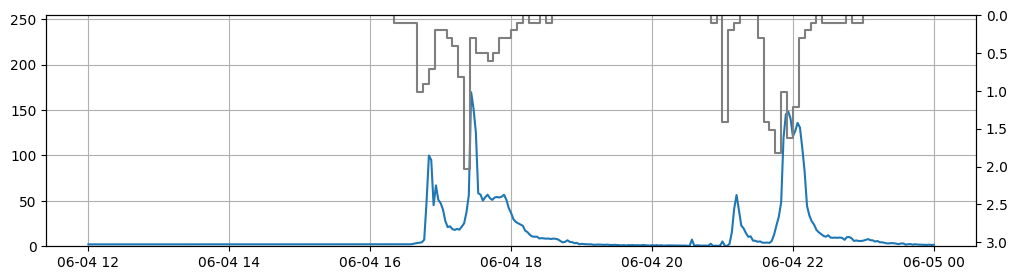

In [89]:
window = ["2023-06-04 12:00", "2023-06-05 00:00"]

s_qtemp = s_q[window[0]:window[1]]
s_ptemp = s_p.shift(freq="2h")[window[0]:window[1]]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_qtemp)
ax.set_ylim(0, 1.5*s_qtemp.max())

ax2 = ax.twinx()
ax2.plot(s_ptemp, drawstyle="steps-pre", label="Precipitation [mm]", c="tab:grey")
ax2.set_ylim(0, 1.5*s_ptemp.max())
ax2.invert_yaxis()

ax.grid(axis="both")

<Axes: ylabel='Frequency'>

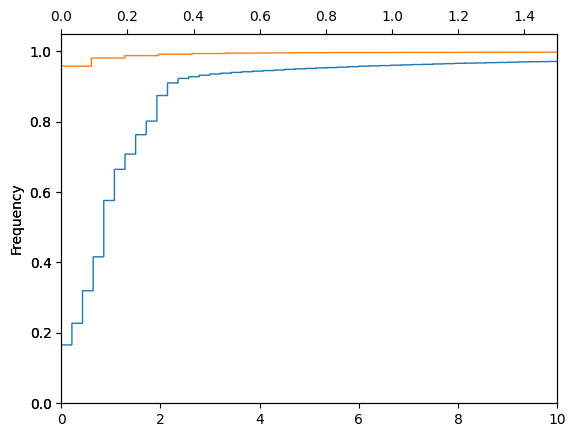

In [54]:
fig, ax1 = plt.subplots()

s_q.plot.hist(cumulative=True, bins=2000, xlim=(0, 10), density=True, ax=ax1, histtype="step")

ax2 = ax1.twiny()
s_p.plot.hist(cumulative=True, bins=1000, density=True, ax=ax2, histtype="step", color="tab:orange", xlim=(0, 1.5))

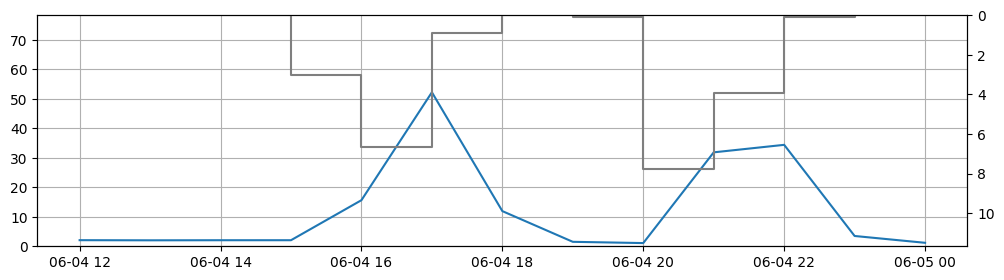

In [107]:
window = ["2023-06-04 12:00", "2023-06-05 00:00"]

s_ptempa = s_p.shift(freq="2h").resample("1h").sum().rename("p_mm/h")[window[0]:window[1]]
s_qtempa = s_q.resample("1h").mean().rename("q_l/s")[window[0]:window[1]]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(s_qtempa)
ax.set_ylim(0, 1.5*s_qtempa.max())

ax2 = ax.twinx()
ax2.plot(s_ptempa, drawstyle="steps-pre", label="Precipitation [mm]", c="tab:grey")
ax2.set_ylim(0, 1.5*s_ptempa.max())
ax2.invert_yaxis()

ax.grid(axis="both")

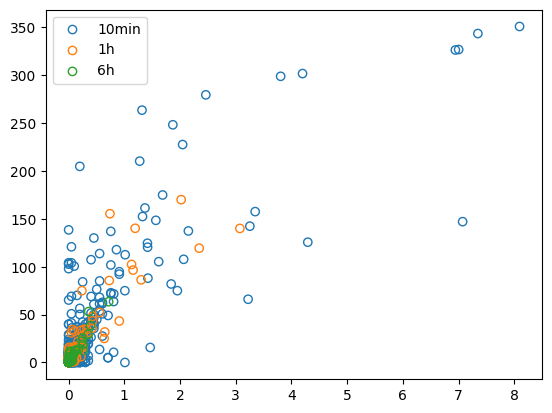

In [137]:
freqs = ["10min", "1h", "6h"]
fig, ax = plt.subplots()

import matplotlib as mpl
colors = mpl.colormaps['tab10'].colors

for i, freq in enumerate(freqs):
    df = pd.concat([s_p.shift(freq="2h").resample(freq).mean().rename("p_mm/5min"), s_q.resample(freq).mean().rename("q_l/s")], axis=1)
    ax.scatter(x=df["p_mm/5min"], y=df["q_l/s"], facecolor="none", edgecolors=colors[i], label=freq)
ax.legend()